# HyperSense v1.1 – BMI-Enhanced Model Development

This notebook evaluates the impact of incorporating Body Mass Index (BMI) into the HyperSense hypertension risk screening model.

The original HyperSense v1.0 model was trained using five non-invasive predictors:

- Age
- Sex
- Residence
- Educational Level
- Tobacco Use

While the v1.0 model achieved acceptable discrimination, SHAP analysis demonstrated that age dominated prediction performance, with limited contribution from the remaining variables.

To improve clinical relevance and potentially enhance predictive performance, this notebook investigates the inclusion of BMI as an additional predictor.

Because BMI measurements were unavailable for a substantial proportion of respondents, introducing BMI requires restricting analysis to participants with complete BMI data. This creates a trade-off between sample size and predictor quality.

Objectives:

1. Construct a BMI-complete modelling dataset.
2. Retrain the HyperSense model with BMI included.
3. Compare predictive performance against HyperSense v1.0.
4. Evaluate feature importance using SHAP.
5. Determine whether the BMI-enhanced model should replace the current production model.

This notebook represents the development workflow for HyperSense v1.1.

In [135]:
# LIBRARIES

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Model development
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

# Baseline models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

# Calibration
from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)  

# Model persistence
import joblib

# Explainability
import shap

# Notebook settings
pd.set_option("display.max_columns", None)

#### 1. Load BMI-Complete Dataset

In [136]:
# Load dataset
model_v2_df = pd.read_csv("../outputs/hypersense_v2_data.csv")

print(model_v2_df.shape)
model_v2_df.head()

(7844, 10)


,caseid,country,sample_weight,age,gender,residence,educational_level,tobacco_use,htn_status,bmi
0,1 1 1,Ghana,856663.0,50.0,1,0,2,0,1.0,1703.0
1,1 3 1,Ghana,856663.0,27.0,1,0,2,0,0.0,2048.0
2,1 6 1,Ghana,856663.0,24.0,1,0,2,0,0.0,2108.0
3,111 1,Ghana,856663.0,40.0,1,0,1,1,0.0,1972.0
4,119 1,Ghana,856663.0,43.0,1,0,2,0,0.0,2300.0


#### 2. Dataset Characteristics

In [137]:
model_v2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7844 entries, 0 to 7843
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   caseid             7844 non-null   object 
 1   country            7844 non-null   object 
 2   sample_weight      7844 non-null   float64
 3   age                7844 non-null   float64
 4   gender             7844 non-null   int64  
 5   residence          7844 non-null   int64  
 6   educational_level  7844 non-null   int64  
 7   tobacco_use        7844 non-null   int64  
 8   htn_status         7844 non-null   float64
 9   bmi                7844 non-null   float64
dtypes: float64(4), int64(4), object(2)
memory usage: 612.9+ KB


In [138]:
# Brief descriptive stats
model_v2_df.describe().T

,count,mean,std,min,25%,50%,75%,max
sample_weight,7844.0,999739.913310,706131.514230,94252.0,581831.0,819798.0,1252350.0,5980193.0
age,7844.0,32.502805,10.831072,15.0,24.0,32.0,40.0,59.0
gender,7844.0,0.395334,0.488953,0.0,0.0,0.0,1.0,1.0
residence,7844.0,0.484574,0.499794,0.0,0.0,0.0,1.0,1.0
educational_level,7844.0,1.462774,0.924549,0.0,1.0,2.0,2.0,3.0
tobacco_use,7844.0,0.039903,0.195744,0.0,0.0,0.0,0.0,1.0
htn_status,7844.0,0.115375,0.319494,0.0,0.0,0.0,0.0,1.0
bmi,7844.0,2354.533911,454.071756,1334.0,2043.0,2253.0,2559.0,5435.0


In [139]:
# Random BMI values

model_v2_df["bmi"].sample(
    10,
    random_state=42
)

7641    3742.0
2166    1965.0
3422    2577.0
1905    3002.0
1454    2072.0
3307    2702.0
4845    2758.0
2464    2063.0
7710    2801.0
6259    2707.0
Name: bmi, dtype: float64

In [140]:
# Test scaling

(
    model_v2_df["bmi"] / 100
).describe()

count    7844.000000
mean       23.545339
std         4.540718
min        13.340000
25%        20.430000
50%        22.530000
75%        25.590000
max        54.350000
Name: bmi, dtype: float64

In [141]:
# Scaling BMI to appropriate values
model_v2_df["bmi"] = (
    model_v2_df["bmi"] / 100
)

In [142]:
# Quality check - BMI distribution

model_v2_df["bmi"].describe()

count    7844.000000
mean       23.545339
std         4.540718
min        13.340000
25%        20.430000
50%        22.530000
75%        25.590000
max        54.350000
Name: bmi, dtype: float64

In [143]:
# Check unlikely/impossible BMI values

model_v2_df[
    (model_v2_df["bmi"] < 10)
    |
    (model_v2_df["bmi"] > 60)
]

,caseid,country,sample_weight,age,gender,residence,educational_level,tobacco_use,htn_status,bmi


In [144]:
# Country representation

model_v2_df["country"].value_counts()

country
Ghana    7844
Name: count, dtype: int64

In [145]:
# Country percentages

model_v2_df["country"].value_counts(
    normalize=True
) * 100

country
Ghana    100.0
Name: proportion, dtype: float64

In [146]:
# Country × Gender breakdown

pd.crosstab(
    model_v2_df["country"],
    model_v2_df["gender"]
)

gender,0,1
country,,
Ghana,4743,3101


In [147]:
# Hypertension prevalence

print(model_v2_df["htn_status"].mean())

print(
    f"Hypertension prevalence: "
    f"{model_v2_df['htn_status'].mean()*100:.1f}%"
)

0.11537480877103519
Hypertension prevalence: 11.5%


In [148]:
# Mean BMI by hypertension status

model_v2_df.groupby(
    "htn_status"
)["bmi"].mean()

htn_status
0.0    23.220388
1.0    26.036873
Name: bmi, dtype: float64

In [149]:
# Correlation matrix

corr_cols = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use",
    "bmi",
    "htn_status"
]

model_v2_df[
    corr_cols
].corr(numeric_only=True)

,age,gender,residence,educational_level,tobacco_use,bmi,htn_status
age,1.000000,0.320130,-0.018517,-0.156422,0.162594,0.177168,0.264770
gender,0.320130,1.000000,-0.012869,0.118724,0.225485,-0.223410,0.081800
residence,-0.018517,-0.012869,1.000000,0.295794,-0.079072,0.228914,0.083410
educational_level,-0.156422,0.118724,0.295794,1.000000,-0.139390,0.120796,0.044541
tobacco_use,0.162594,0.225485,-0.079072,-0.139390,1.000000,-0.122770,0.001810
bmi,0.177168,-0.223410,0.228914,0.120796,-0.122770,1.000000,0.198174
htn_status,0.264770,0.081800,0.083410,0.044541,0.001810,0.198174,1.000000


#### 3. Feature Selection

In [150]:
# 3. FEATURE SELECTION

# Candidate predictors
candidate_features = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use",
    "bmi"
]

target = "htn_status"

print("Candidate Features:")
for feature in candidate_features:
    print(f"- {feature}")

Candidate Features:
- age
- gender
- residence
- educational_level
- tobacco_use
- bmi


In [151]:
# Missing value check

model_v2_df[
    candidate_features + [target]
].isnull().sum()

age                  0
gender               0
residence            0
educational_level    0
tobacco_use          0
bmi                  0
htn_status           0
dtype: int64

In [152]:
# Feature-target correlations

feature_correlations = (
    model_v2_df[
        candidate_features + [target]
    ]
    .corr(numeric_only=True)[target]
    .sort_values(
        ascending=False
    )
)

feature_correlations

htn_status           1.000000
age                  0.264770
bmi                  0.198174
residence            0.083410
gender               0.081800
educational_level    0.044541
tobacco_use          0.001810
Name: htn_status, dtype: float64

In [153]:
# Correlation summary

correlation_df = pd.DataFrame({
    "Feature": feature_correlations.index,
    "Correlation_With_HTN": feature_correlations.values
})

correlation_df

,Feature,Correlation_With_HTN
0,htn_status,1.000000
1,age,0.264770
2,bmi,0.198174
3,residence,0.083410
4,gender,0.081800
5,educational_level,0.044541
6,tobacco_use,0.001810


In [154]:
# Final feature set

FEATURES = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use",
    "bmi"
]

TARGET = "htn_status"

WEIGHT = "sample_weight"

print("Final Features:")
print(FEATURES)

print(f"\nNumber of Features: {len(FEATURES)}")

Final Features:
['age', 'gender', 'residence', 'educational_level', 'tobacco_use', 'bmi']

Number of Features: 6


#### 4. Train-Test Split

In [155]:
# Create feature matrix and target vector

X = model_v2_df[FEATURES]

y = model_v2_df[TARGET]

weights = model_v2_df[WEIGHT]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (7844, 6)
Target Shape: (7844,)


In [156]:
# Stratified train-test split

X_train, X_test, y_train, y_test, w_train, w_test = (
    train_test_split(
        X,
        y,
        weights,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print("Training Set Shape:")
print(X_train.shape)

print("\nTest Set Shape:")
print(X_test.shape)

Training Set Shape:
(6275, 6)

Test Set Shape:
(1569, 6)


In [157]:
# CLASS IMBALANCE ASSESSMENT

negative_class = (y_train == 0).sum()

positive_class = (y_train == 1).sum()

scale_pos_weight = negative_class / positive_class

print(f"Negative cases: {negative_class}")
print(f"Positive cases: {positive_class}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Negative cases: 5551
Positive cases: 724
scale_pos_weight: 7.67


In [158]:
# SPLIT SUMMARY

print(f"Training observations : {len(X_train):,}")
print(f"Testing observations  : {len(X_test):,}")

print(f"Predictors            : {X_train.shape[1]}")
print(f"Target prevalence     : {y_train.mean()*100:.2f}%")

Training observations : 6,275
Testing observations  : 1,569
Predictors            : 6
Target prevalence     : 11.54%


#### 5. Model Development & Evaluation

In [159]:
# DUMMY CLASSIFIER BASELINE

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_test)
dummy_prob = dummy_model.predict_proba(X_test)[:, 1]

In [160]:
# Function for model evaluation
def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    
    print("=" * 60)
    print(model_name.upper())
    print("=" * 60)

    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, zero_division=0):.4f}")

    if y_prob is not None:
        print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")
        print(f"Brier    : {brier_score_loss(y_true, y_prob):.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

In [161]:
# Evaluate the dummy classifier
evaluate_model(
    model_name="Dummy classifier",
    y_true=y_test,
    y_pred=dummy_pred,
    y_prob=dummy_prob
)

DUMMY CLASSIFIER
Accuracy : 0.8846
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.5000
Brier    : 0.1154

Confusion Matrix
[[1388    0]
 [ 181    0]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94      1388
         1.0       0.00      0.00      0.00       181

    accuracy                           0.88      1569
   macro avg       0.44      0.50      0.47      1569
weighted avg       0.78      0.88      0.83      1569



In [162]:
# LOGISTIC REGRESSION


log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

log_pred = log_reg.predict(X_test)
log_prob = log_reg.predict_proba(X_test)[:, 1]

In [163]:
# Evaluate the log reg model
evaluate_model(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=log_pred,
    y_prob=log_prob
)

LOGISTIC REGRESSION
Accuracy : 0.7119
Precision: 0.2448
Recall   : 0.7182
F1 Score : 0.3652
ROC-AUC  : 0.7943
Brier    : 0.1873

Confusion Matrix
[[987 401]
 [ 51 130]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.95      0.71      0.81      1388
         1.0       0.24      0.72      0.37       181

    accuracy                           0.71      1569
   macro avg       0.60      0.71      0.59      1569
weighted avg       0.87      0.71      0.76      1569



In [164]:
# RANDOM FOREST

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [165]:
# Evaluate Random Forest Model

evaluate_model(
    model_name="Random forest",
    y_true=y_test,
    y_pred=rf_pred,
    y_prob=rf_prob
)

RANDOM FOREST
Accuracy : 0.7043
Precision: 0.2432
Recall   : 0.7403
F1 Score : 0.3661
ROC-AUC  : 0.7883
Brier    : 0.1798

Confusion Matrix
[[971 417]
 [ 47 134]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.95      0.70      0.81      1388
         1.0       0.24      0.74      0.37       181

    accuracy                           0.70      1569
   macro avg       0.60      0.72      0.59      1569
weighted avg       0.87      0.70      0.76      1569



In [166]:
# STEP 9: XGBOOST

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1
)

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [167]:
xgb_pred

array([0, 1, 1, ..., 0, 0, 0], shape=(1569,))

In [168]:
# Evaluate the XGB model

evaluate_model(
    model_name="XGBoost",
    y_true=y_test,
    y_pred=xgb_pred,
    y_prob=xgb_prob
)

XGBOOST
Accuracy : 0.6973
Precision: 0.2278
Recall   : 0.6796
F1 Score : 0.3412
ROC-AUC  : 0.7624
Brier    : 0.1854

Confusion Matrix
[[971 417]
 [ 58 123]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.94      0.70      0.80      1388
         1.0       0.23      0.68      0.34       181

    accuracy                           0.70      1569
   macro avg       0.59      0.69      0.57      1569
weighted avg       0.86      0.70      0.75      1569



In [169]:
#  MODEL COMPARISON

comparison_df = pd.DataFrame({
    "Model": [
        "Dummy",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, dummy_pred),
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,ROC_AUC
1,Logistic Regression,0.794338
2,Random Forest,0.788320
3,XGBoost,0.762399
0,Dummy,0.500000


In [170]:
# FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": xgb_model.feature_importances_
})

feature_importance.sort_values(
    by="importance",
    ascending=False
)

,feature,importance
0,age,0.294906
5,bmi,0.173868
1,gender,0.171189
2,residence,0.132504
4,tobacco_use,0.125926
3,educational_level,0.101608


In [171]:
# MODEL COMPARISON TABLE

comparison_df = pd.DataFrame({
    "Model": [
        "Dummy",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, dummy_prob),
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],
    "F1": [
        f1_score(y_test, dummy_pred),
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, dummy_pred),
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, dummy_pred, zero_division=0),
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ]
})

comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,ROC_AUC,F1,Recall,Precision
1,Logistic Regression,0.794338,0.365169,0.718232,0.244821
2,Random Forest,0.788320,0.366120,0.740331,0.243194
3,XGBoost,0.762399,0.341193,0.679558,0.227778
0,Dummy,0.500000,0.000000,0.000000,0.000000


#### 6. XGBoost Hyperparam Tuning

In [172]:
# XGBOOST HYPERPARAMETER TUNING

# Base estimator
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
)

# Search space
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "scale_pos_weight": [5, 7.7, 10]
}

# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Random search
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=100,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit search
random_search.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [173]:
# TRAIN FINAL TUNED XGBOOST

best_xgb = random_search.best_estimator_

best_xgb.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [174]:
# EVALUATE TUNED XGBOOST

best_xgb_pred = best_xgb.predict(
    X_test
)

best_xgb_prob = best_xgb.predict_proba(
    X_test
)[:, 1]

evaluate_model(
    model_name="Tuned XGBoost",
    y_true=y_test,
    y_pred=best_xgb_pred,
    y_prob=best_xgb_prob
)

TUNED XGBOOST
Accuracy : 0.6048
Precision: 0.2022
Recall   : 0.8232
F1 Score : 0.3246
ROC-AUC  : 0.7916
Brier    : 0.2355

Confusion Matrix
[[800 588]
 [ 32 149]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.96      0.58      0.72      1388
         1.0       0.20      0.82      0.32       181

    accuracy                           0.60      1569
   macro avg       0.58      0.70      0.52      1569
weighted avg       0.87      0.60      0.68      1569



In [175]:
# FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": best_xgb.feature_importances_
})

feature_importance.sort_values(
    by="importance",
    ascending=False
)

,feature,importance
0,age,0.463444
5,bmi,0.180132
1,gender,0.136202
2,residence,0.094856
4,tobacco_use,0.064471
3,educational_level,0.060894


In [176]:
# FINAL MODEL COMPARISON

final_comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, best_xgb_prob)
    ],
    "F1": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, best_xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, best_xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, best_xgb_pred)
    ]
})

final_comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,ROC_AUC,F1,Recall,Precision
0,Logistic Regression,0.794338,0.365169,0.718232,0.244821
3,Tuned XGBoost,0.791639,0.324619,0.823204,0.202171
1,Random Forest,0.788320,0.366120,0.740331,0.243194
2,Baseline XGBoost,0.762399,0.341193,0.679558,0.227778


#### 7. Threshold Optimization

In [177]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    
    pred = (
        best_xgb_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred
        ),
        "F1": f1_score(
            y_test,
            pred
        ),
        "High_Risk_Rate": pred.mean()
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.sort_values(
    by="F1",
    ascending=False
)

,Threshold,Precision,Recall,F1,High_Risk_Rate
12,0.70,0.331169,0.563536,0.417178,0.196303
11,0.65,0.282353,0.662983,0.396040,0.270873
13,0.75,0.383721,0.364641,0.373938,0.109624
10,0.60,0.240876,0.729282,0.362140,0.349267
9,0.55,0.209408,0.762431,0.328571,0.420013
8,0.50,0.202171,0.823204,0.324619,0.469726
7,0.45,0.189320,0.861878,0.310448,0.525175
6,0.40,0.170968,0.878453,0.286229,0.592734
5,0.35,0.163343,0.950276,0.278768,0.671128
4,0.30,0.153713,0.983425,0.265870,0.738050


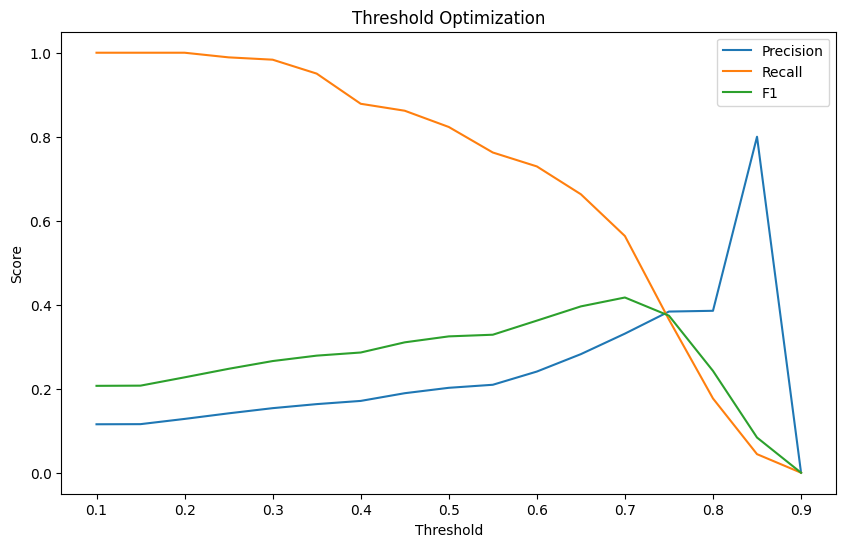

In [178]:
# Visualize
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()

plt.show()

**Selected Model:**
Tuned XGBoost

**Selected Threshold:**
0.50

**Selection Rationale:**
HyperSense is intended as a screening tool rather than a diagnostic tool. Threshold selection prioritized sensitivity (recall) over balanced classification performance to minimize missed high-risk individuals.

#### 8. Model Explainability (SHAP)

In [179]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

In [180]:
# CREATE SHAP EXPLAINER

explainer = shap.TreeExplainer(
    best_xgb
)

shap_values = explainer.shap_values(
    X_test
)

print("SHAP values generated successfully.")
print(f"Shape: {shap_values.shape}")

SHAP values generated successfully.
Shape: (1569, 6)


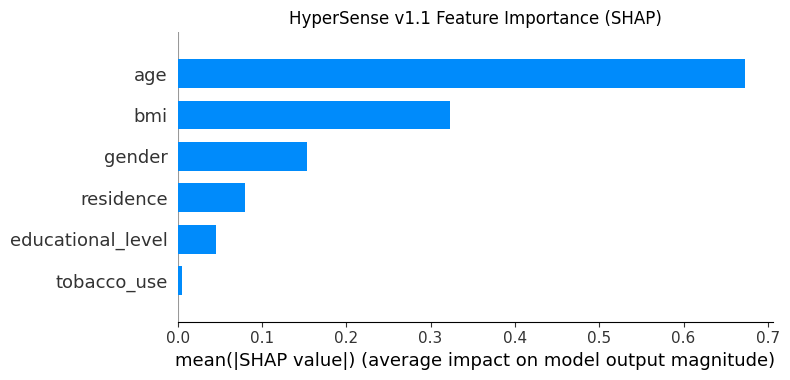

In [181]:
# GLOBAL FEATURE IMPORTANCE

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title(
    "HyperSense v1.1 Feature Importance (SHAP)"
)

plt.tight_layout()

plt.savefig(
    "../outputs/shap_global_importance_v11.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

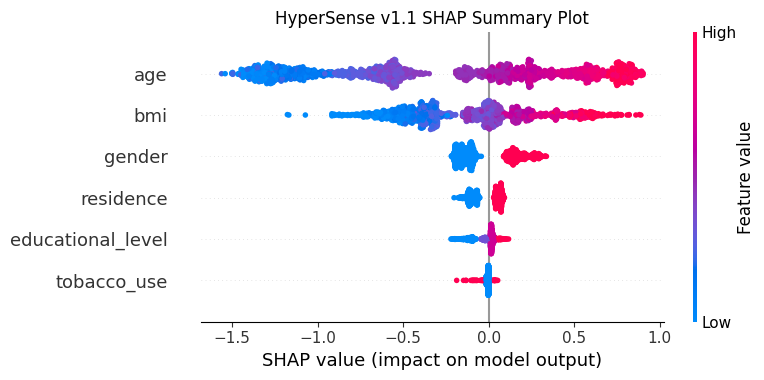

In [182]:
# SHAP BEESWARM PLOT

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title(
    "HyperSense v1.1 SHAP Summary Plot"
)

plt.tight_layout()

plt.savefig(
    "../outputs/shap_beeswarm_v11.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [183]:
# FEATURE IMPORTANCE TABLE

mean_abs_shap = np.abs(
    shap_values
).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": mean_abs_shap
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        by="mean_abs_shap",
        ascending=False
    )
)

shap_importance_df

,feature,mean_abs_shap
0,age,0.672465
5,bmi,0.322541
1,gender,0.153988
2,residence,0.080362
3,educational_level,0.045733
4,tobacco_use,0.005521


In [184]:
# SAVE SHAP IMPORTANCE TABLE

shap_importance_df.to_csv(
    "../outputs/shap_importance_v11.csv",
    index=False
)

print(
    "SHAP importance table saved."
)

SHAP importance table saved.


In [185]:
# HIGH-RISK EXAMPLE

threshold = 0.50
test_probabilities = best_xgb.predict_proba(
    X_test
)[:, 1]

high_risk_idx = np.where(
    test_probabilities >= threshold
)[0][0]

print(
    f"Selected index: {high_risk_idx}"
)

X_test.iloc[
    high_risk_idx
]

Selected index: 1


age                  44.00
gender                0.00
residence             0.00
educational_level     0.00
tobacco_use           0.00
bmi                  25.27
Name: 3363, dtype: float64

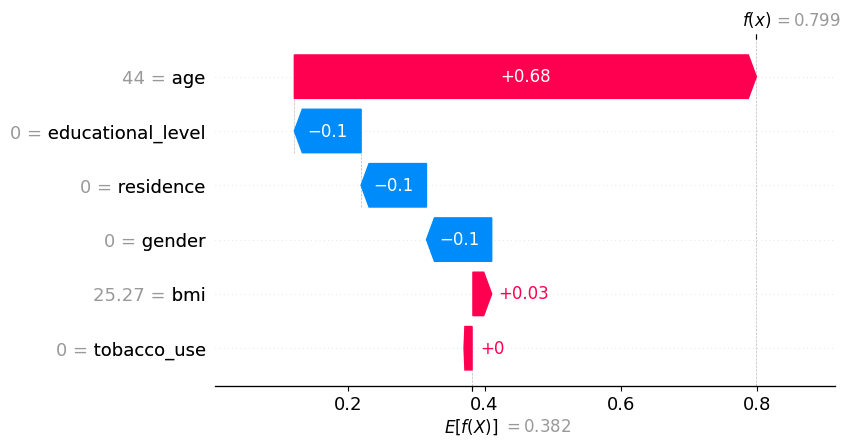

In [186]:
# WATERFALL EXPLANATION

single_explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=FEATURES
)

shap.plots.waterfall(
    single_explanation,
    max_display=10
)

In [187]:
# SAVE WATERFALL PLOT

plt.figure(figsize=(10, 6))

shap.plots.waterfall(
    single_explanation,
    max_display=10,
    show=False
)

plt.savefig(
    "../outputs/shap_waterfall_v11.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

### Key Findings

- Age remained the strongest predictor of hypertension risk.
- BMI emerged as the second most important feature after inclusion in v1.1.
- Higher age and BMI values generally increased predicted hypertension risk.
- The final tuned XGBoost model achieved a ROC-AUC of approximately 0.79.
- A deployment threshold of 0.50 was selected to prioritize sensitivity in a screening context.
- At the selected threshold, the model identified approximately 82% of hypertensive individuals in the test set.

In [188]:
random_search.best_params_

{'subsample': 0.8,
 'scale_pos_weight': 10,
 'n_estimators': 300,
 'min_child_weight': 7,
 'max_depth': 3,
 'learning_rate': 0.01,
 'gamma': 0,
 'colsample_bytree': 0.8}

In [189]:
DEPLOYMENT_THRESHOLD = 0.50

#### 9. Model Export

In [190]:
# dump right away

joblib.dump(
    best_xgb,
    "../models/hypersense_xgb_v11.pkl"
)

joblib.dump(
    0.50,
    "../models/hypersense_threshold_v11.pkl"
)

print("Model exported successfully.")

Model exported successfully.
